<a href="https://colab.research.google.com/github/Charlx96/Proyecto-de-regresion-lineal-y-logistico/blob/main/proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns


In [60]:
df = pd.read_csv("Ecommerce Customers.csv")
df.head(15)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
5,alvareznancy@lucas.biz,"645 Martha Park Apt. 611\nJeffreychester, MN 6...",FloralWhite,33.871038,12.026925,34.476878,5.493507,637.102448
6,katherine20@yahoo.com,"68388 Reyes Lights Suite 692\nJosephbury, WV 9...",DarkSlateBlue,32.021596,11.366348,36.683776,4.685017,521.572175
7,awatkins@yahoo.com,Unit 6538 Box 8980\nDPO AP 09026-4941,Aqua,32.739143,12.351959,37.373359,4.434273,549.904146
8,vchurch@walter-martinez.com,"860 Lee Key\nWest Debra, SD 97450-0495",Salmon,33.987773,13.386235,37.534497,3.273434,570.200409
9,bonnie69@lin.biz,"PSC 2734, Box 5255\nAPO AA 98456-7482",Brown,31.936549,11.814128,37.145168,3.202806,427.199385


In [61]:
df.shape

(500, 8)

In [62]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


Como vemos no tenemos valores faltantes. por tanto podemos proseguir con el codigo

In [64]:
X= df[["Length of Membership","Time on App"]]
y= df["Yearly Amount Spent"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=123 )


In [65]:
pred_baseline_train = np.repeat(y_train.mean(), len(y_train))
pred_baseline_test = np.repeat(y_train.mean(), len(y_test))

modelo_multi = LinearRegression()
modelo_multi.fit(X_train, y_train)

pred_multi_train = modelo_multi.predict(X_train)
pred_multi_test = modelo_multi.predict(X_test)

In [66]:
def calcular_kpis(valores_reales, valores_predichos, nombre_tag):
  mae = mean_absolute_error(valores_reales, valores_predichos)
  rmse = np.sqrt(mean_squared_error(valores_reales, valores_predichos))
  mape = np.mean(np.abs((valores_reales - valores_predichos) / valores_reales)) * 100
  r2 = r2_score(valores_reales, valores_predichos)

  return pd.DataFrame({
      'Escenario': [nombre_tag],
      'R_Cuadrado': [round(r2, 3)],
      'MAE_USD': [round(mae, 0)],
      'RMSE_USD': [round(rmse, 0)],
      'MAPE_Porcentaje': [f"{round(mape, 1)}%"]
  })

tabla_resultados = pd.concat([
    calcular_kpis(y_train, pred_baseline_train, "Baseline (Train)"),
    calcular_kpis(y_test, pred_baseline_test, "Baseline (Test)"),

    calcular_kpis(y_train, pred_multi_train, "Modelo Multivariado (Train)"),
    calcular_kpis(y_test, pred_multi_test, "Modelo Multivariado (Test)")
], ignore_index=True)

print("\n=== TABLA COMPARATIVA DE RENDIMIENTO ===")
print(tabla_resultados.to_string(index=False))


=== TABLA COMPARATIVA DE RENDIMIENTO ===
                  Escenario  R_Cuadrado  MAE_USD  RMSE_USD MAPE_Porcentaje
           Baseline (Train)       0.000     60.0      78.0           12.9%
            Baseline (Test)      -0.000     67.0      83.0           14.1%
Modelo Multivariado (Train)       0.875     22.0      28.0            4.6%
 Modelo Multivariado (Test)       0.903     22.0      26.0            4.5%


In [67]:
print("\n=== COEFICIENTES DEL MODELO MULTIVARIABLE ===")
df_coeficientes = pd.DataFrame({
    'Variable': ['Intercepto (const)'] + list(X_train.columns),
    'Coeficiente (coef)': [modelo_multi.intercept_] + list(modelo_multi.coef_)
})
print(df_coeficientes.to_string(index=False))


=== COEFICIENTES DEL MODELO MULTIVARIABLE ===
            Variable  Coeficiente (coef)
  Intercepto (const)         -181.283233
Length of Membership           62.886433
         Time on App           38.032882


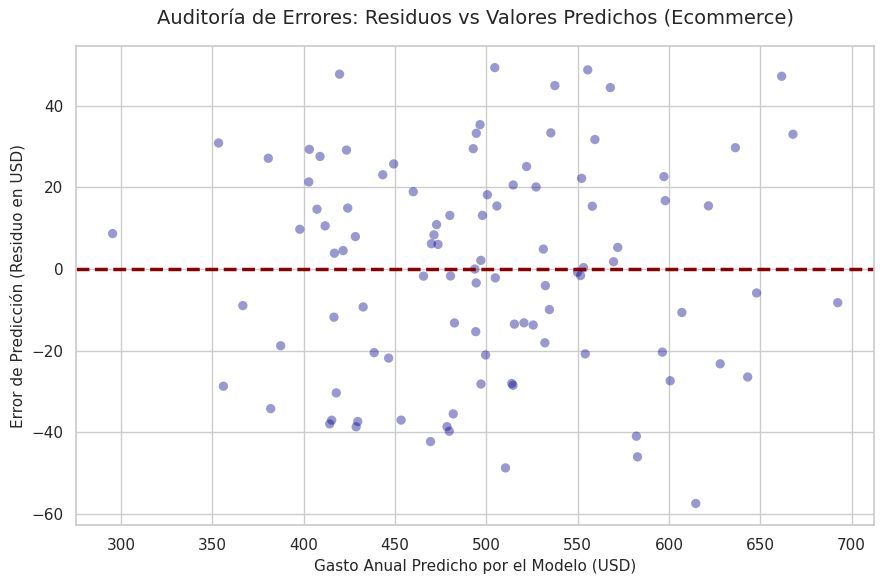

In [68]:
# 1. Calcular los residuos del set de prueba (Valor Real - Valor Predicho)
residuos_test = y_test - pred_multi_test

# 2. Configurar el lienzo gráfico
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# 3. Dibujar los puntos (Predicciones vs Residuos)
plt.scatter(pred_multi_test, residuos_test, color='darkblue', alpha=0.4, edgecolors='none', s=45)

# 4. Dibujar la línea de referencia en el cero (Perfección)
plt.axhline(y=0, color='darkred', linestyle='--', linewidth=2.5)

# 5. Personalizar etiquetas y títulos ejecutivos
plt.title("Auditoría de Errores: Residuos vs Valores Predichos (Ecommerce)", fontsize=14, pad=15)
plt.xlabel("Gasto Anual Predicho por el Modelo (USD)", fontsize=11)
plt.ylabel("Error de Predicción (Residuo en USD)", fontsize=11)

# 6. Ajustar y mostrar la gráfica
plt.tight_layout()
plt.show()

Para realizar una regresion logistica en este dataset, necesitamos una columna con alguna variable a predecir, como no tenemos ninguna nos haremos de una

en base a que si un cliente usa muy poco la app,y su gasto anual tambien es bajo. Lo categorizaremos como cliente inactivo (propenso a darse de baja), entonces sera un valor de 1 y si no cumple con ambas, se queda como cliente estable (0)

In [69]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [70]:
#usaremos como base, que si el tiempo de uso en la app es menor al percentil 40 "o"
#Su gasto anual está por debajo  (del percentil 40)

umbral_gasto = df['Yearly Amount Spent'].quantile(0.4)
umbral_app = df['Time on App'].quantile(0.4)

#ahora aumentaremos nuestro valor que sera la prediccion, osea la "Y" , dado una columna con valores 1 y 0

df['Riesgo'] = np.where(
    (df['Yearly Amount Spent'] < umbral_gasto) |
    (df['Time on App'] < umbral_app),
    1,0)

df.head()
#como vemos ya tenemos el valor de la columna riesgo con 0 y 1

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,Riesgo
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054,0
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933,1
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505,1
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344,0
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092,0


In [71]:
print(df['Riesgo'].value_counts())

Riesgo
1    282
0    218
Name: count, dtype: int64


In [72]:
#selccionamos la variables predictorias, no las mismas que usamos para determinar 0 y 1

X_log = df[['Avg. Session Length', 'Time on Website', 'Length of Membership']]
y_log = df['Riesgo']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=321)

modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_log, y_train_log)



LogisticRegression()

In [73]:
#mostramos una tabla de los coneficientes

print("\n=== COEFICIENTES DE LA REGRESIÓN LOGÍSTICA ===")
df_coef_log = pd.DataFrame({
    'Variable': ['Intercepto (const)'] + list(X_log.columns),
    'Coeficiente (Log-Odds)': [modelo_logistico.intercept_[0]] + list(modelo_logistico.coef_[0])
})
print(df_coef_log.to_string(index=False))


=== COEFICIENTES DE LA REGRESIÓN LOGÍSTICA ===
            Variable  Coeficiente (Log-Odds)
  Intercepto (const)               13.104149
 Avg. Session Length               -0.305800
     Time on Website                0.000064
Length of Membership               -0.758987


In [74]:
#ahora le damos a nuestro modelo entrenado los datos del test :3
pred_log_test = modelo_logistico.predict(X_test_log)

print("\n=== REPORTE DE CLASIFICACIÓN (MÉTRICAS ) ===")
print(classification_report(y_test_log, pred_log_test))


=== REPORTE DE CLASIFICACIÓN (MÉTRICAS ) ===
              precision    recall  f1-score   support

           0       0.58      0.48      0.52        46
           1       0.61      0.70      0.66        54

    accuracy                           0.60       100
   macro avg       0.60      0.59      0.59       100
weighted avg       0.60      0.60      0.59       100

